In [1]:
import pandas as pd
import numpy as np

In [3]:
# display(adult)

In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Carrega a base
adult = fetch_ucirepo(id=2)

# Features e alvo
X = adult.data.features
y = adult.data.targets

# Junta tudo em um único DataFrame
df = pd.concat([X, y], axis=1)

display(df)



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [5]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

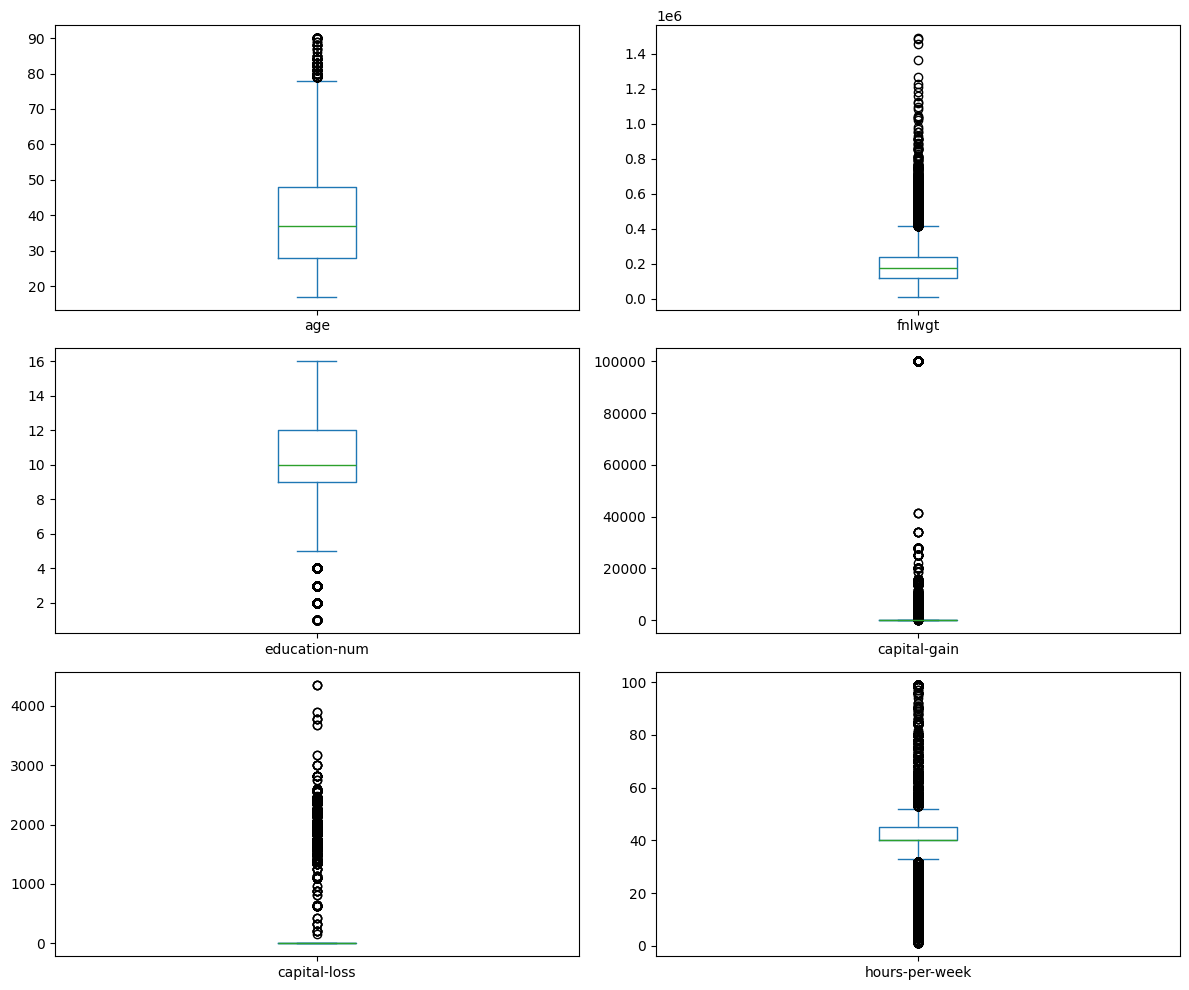

In [6]:
import matplotlib.pyplot as plt

# Colunas numéricas
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

df[colunas_numericas].plot(
    kind="box",
    subplots=True,
    layout=(3, 2),
    figsize=(12, 10),
    sharex=False
)

plt.tight_layout()
plt.show()

In [7]:
# Remove rows with missing values. 
df = df.dropna().reset_index(drop=True)

# Ajuste do tipo de dados da coluna "income"
df["income"] = (
    df["income"]
    .str.strip()                    # Remove espaços
    .str.replace(".", "", regex=False)  # Remove o ponto final
)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Remover coluna redundante
df = df.drop(columns="education-num")

# Variável alvo
X = df.drop(columns="income")
y = df["income"]

# Colunas categóricas
categoricas = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "sex",
    "race",
    "native-country"
]

# Colunas numéricas
numericas = [
    "age",
    "fnlwgt",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ("num", MinMaxScaler(), numericas)
    ]
)



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ajusta somente nos dados de treino
X_train = preprocessor.fit_transform(X_train)

# Aplica a mesma transformação nos dados de teste
X_test = preprocessor.transform(X_test)

In [10]:
# # Modelo
# modelo = DecisionTreeClassifier(random_state=42)
# modelo.fit(X_train, y_train)

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

parametros = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3,5,8,10,15],
    "min_samples_split": [2,5,10,20],
    "min_samples_leaf": [1,5,10]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parametros,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)


# Melhor modelo encontrado
modelo = grid.best_estimator_

print("Melhores parâmetros:")
print(grid.best_params_)

print("\nMelhor F1 médio da validação cruzada:")
print(grid.best_score_)

c:\Users\joth1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Melhores parâmetros:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Melhor F1 médio da validação cruzada:
nan


Acurácia : 0.8208
Precisão : 0.9324
Recall   : 0.2808
F1-Score : 0.4316

Relatório de Classificação
              precision    recall  f1-score   support

       <=50K       0.81      0.99      0.89      7217
        >50K       0.93      0.28      0.43      2308

    accuracy                           0.82      9525
   macro avg       0.87      0.64      0.66      9525
weighted avg       0.84      0.82      0.78      9525



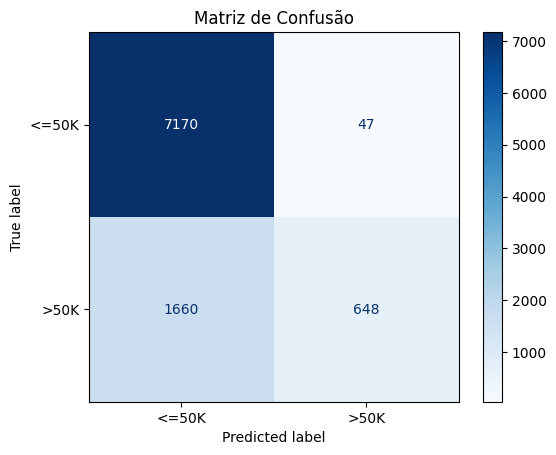

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Previsões
y_pred = modelo.predict(X_test)

# Métricas
print(f"Acurácia : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão : {precision_score(y_test, y_pred, pos_label='>50K'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='>50K'):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, pos_label='>50K'):.4f}")

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

AUC: 0.8242


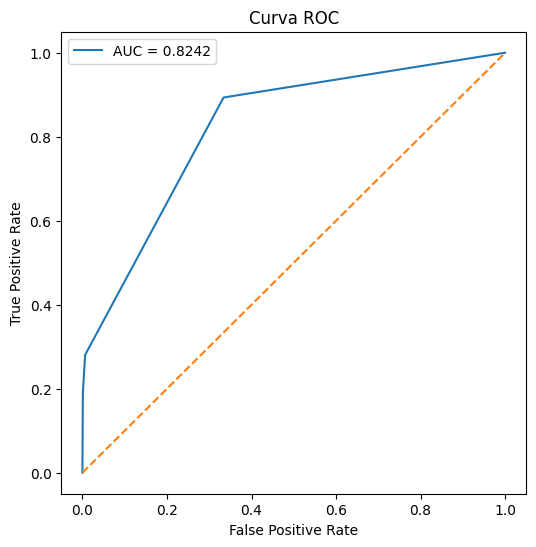

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidade da classe positiva
y_prob = modelo.predict_proba(X_test)[:,1]

# Converter para binário
y_true = (y_test == ">50K").astype(int)

auc = roc_auc_score(y_true, y_prob)

print(f"AUC: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [13]:
gini = 2*auc - 1

print(f"Gini: {gini:.4f}")

Gini: 0.6484


In [14]:
from scipy.stats import ks_2samp
ks = ks_2samp(
    y_prob[y_true==1],
    y_prob[y_true==0]
)
print(f"VALOR DO KS: {ks.statistic:.4f}")




# Importancia das variáveis (Modelo de Árvore de Decisão)
import pandas as pd
features = preprocessor.get_feature_names_out()
imp = pd.DataFrame({
    "Variavel": features,
    "Importancia": modelo.feature_importances_
})

imp = imp.sort_values("Importancia", ascending=False)

print(imp.head(20))

VALOR DO KS: 0.5595
                                   Variavel  Importancia
27   cat__marital-status_Married-civ-spouse     0.586028
104                       num__capital-gain     0.315466
105                       num__capital-loss     0.096466
102                                num__age     0.001625
22                 cat__education_Preschool     0.000414
68          cat__native-country_El-Salvador     0.000000
78              cat__native-country_Hungary     0.000000
77                 cat__native-country_Hong     0.000000
76             cat__native-country_Honduras     0.000000
75   cat__native-country_Holand-Netherlands     0.000000
74                cat__native-country_Haiti     0.000000
73            cat__native-country_Guatemala     0.000000
72               cat__native-country_Greece     0.000000
71              cat__native-country_Germany     0.000000
70               cat__native-country_France     0.000000
69              cat__native-country_England     0.000000
66   cat__n

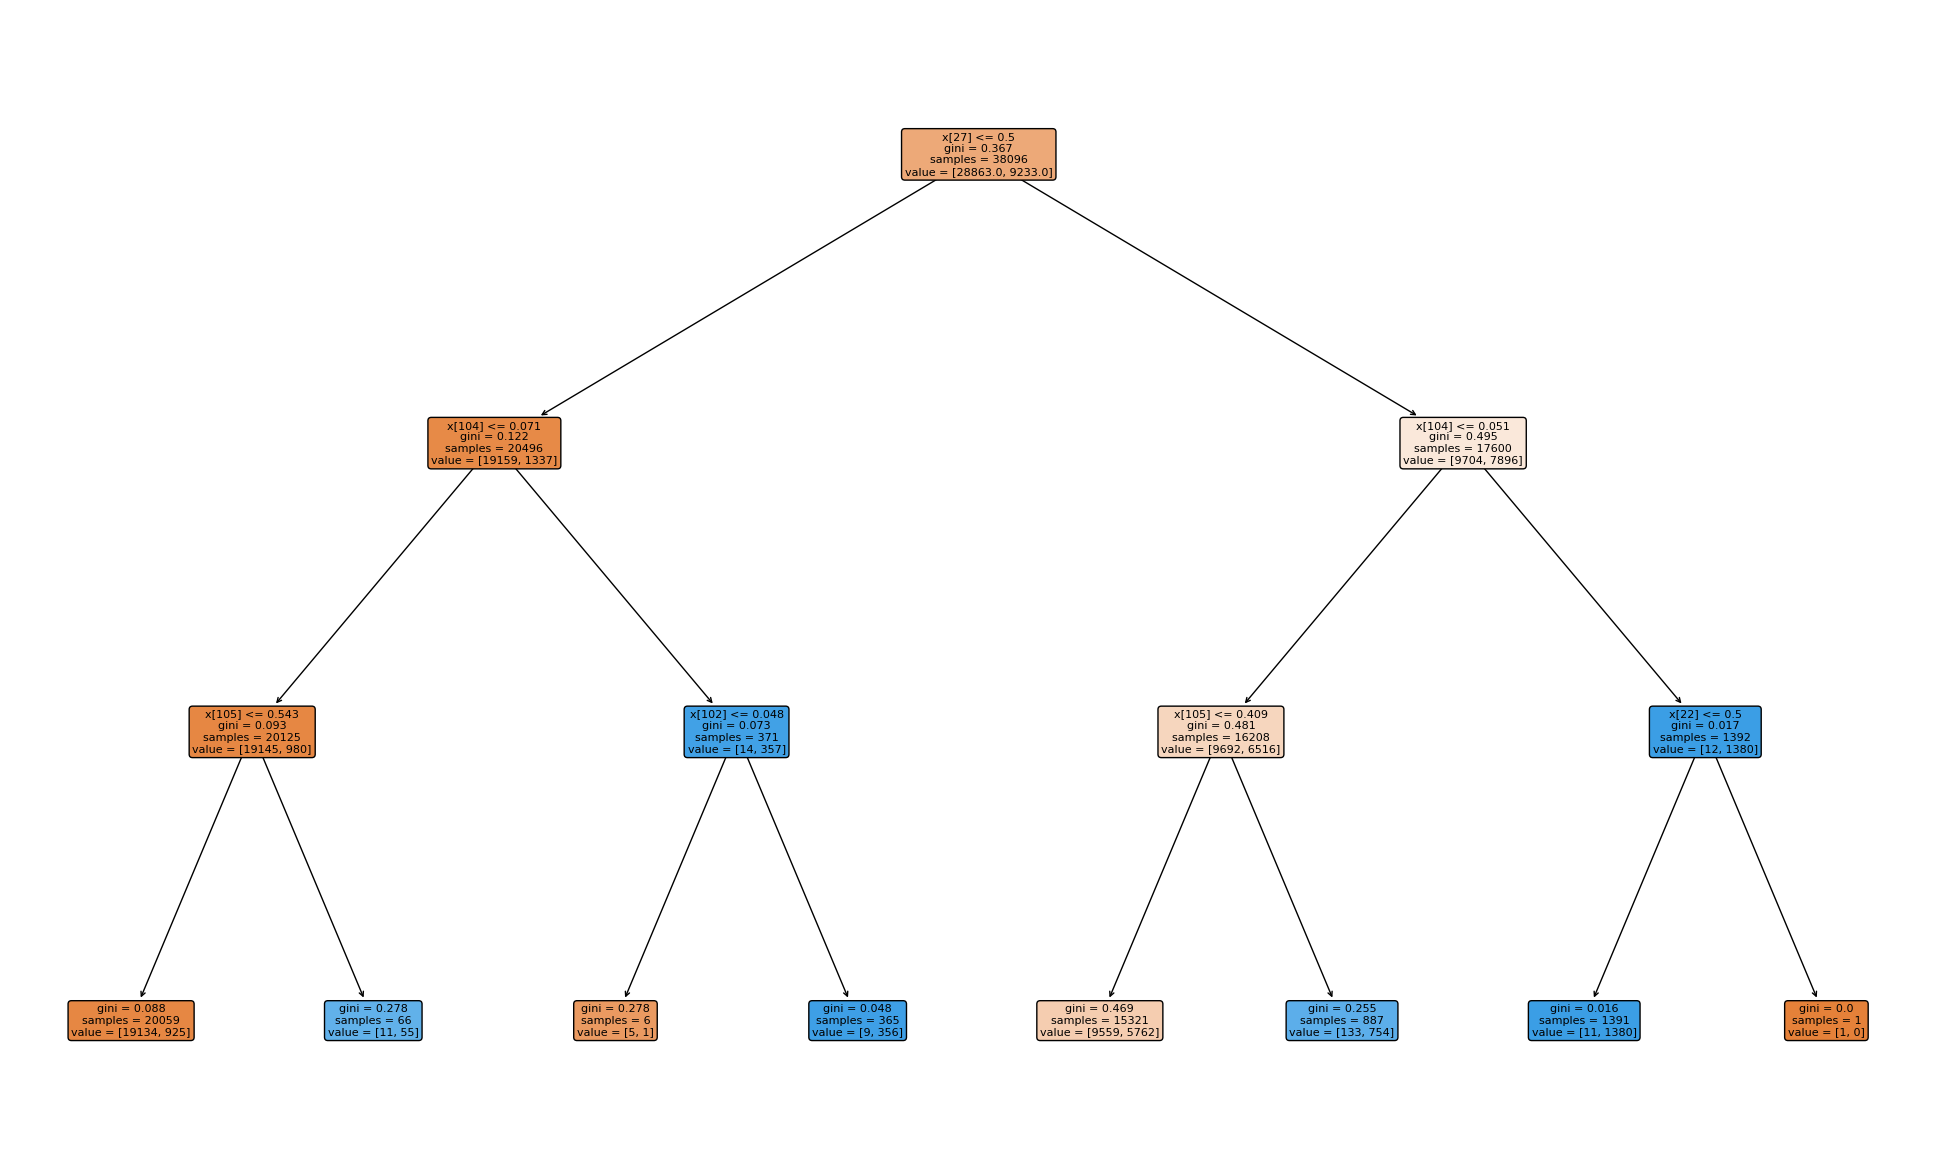

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,15))

plot_tree(
    modelo,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [16]:
import m2cgen as m2c
codigo = m2c.export_to_python(modelo)
print(codigo)

def score(input):
    if input[27] <= 0.5:
        if input[104] <= 0.07055570557713509:
            if input[105] <= 0.5430440902709961:
                var0 = [0.95388603619323, 0.04611396380677003]
            else:
                var0 = [0.16666666666666666, 0.8333333333333334]
        else:
            if input[102] <= 0.04794520512223244:
                var0 = [0.8333333333333334, 0.16666666666666666]
            else:
                var0 = [0.024657534246575342, 0.9753424657534246]
    else:
        if input[104] <= 0.0509555097669363:
            if input[105] <= 0.40920570492744446:
                var0 = [0.6239148880621369, 0.37608511193786304]
            else:
                var0 = [0.14994363021420518, 0.8500563697857948]
        else:
            if input[22] <= 0.5:
                var0 = [0.007907979870596693, 0.9920920201294033]
            else:
                var0 = [1.0, 0.0]
    return var0



##### Curva Precision-Recall

Average Precision (AP): 0.5800


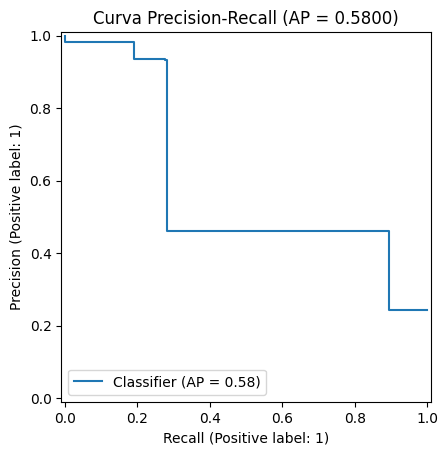

In [17]:
from sklearn.metrics import (
    precision_recall_curve,
    PrecisionRecallDisplay,
    average_precision_score
)

import matplotlib.pyplot as plt

# Probabilidade da classe positiva
y_prob = modelo.predict_proba(X_test)[:, 1]

# Transforma a variável alvo em binária
y_true = (y_test == ">50K").astype(int)

# Average Precision (AP)
ap = average_precision_score(y_true, y_prob)

print(f"Average Precision (AP): {ap:.4f}")

# Curva Precision-Recall
disp = PrecisionRecallDisplay.from_predictions(
    y_true,
    y_prob
)

plt.title(f"Curva Precision-Recall (AP = {ap:.4f})")
plt.show()